# Визуальная сводка: все модели и утверждения на одном экране

Ноутбук собирает **по одному графику на каждое ключевое утверждение**, чтобы
не путаться в моделях. Разделы:

1. **Иерархия моделей** — кто кого бьёт по каждому таргету.
2. **Прямое сравнение со статьёй** (с доверительными интервалами).
3. **Почему `xuv_max` не сравнивают со статьёй «в целом»** — разным таргетам
   нужны разные пятёрки.
4. **Почему best-of-k — спорная метрика** — падает с ростом k даже без модели.
5. **Что честно, а что нет** — итоговая шпаргалка.

Числа кросс-модельного сравнения взяты из соответствующих ноутбуков
(`paper_comparison`, `aux_conditioning`, `xuv_max`); графики про кандидатов
считаются живьём из кэша `aux_data/xuv_candidates.npz`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# результаты моделей (best-of-5, из выполненных ноутбуков)
MODELS = {
    "публикация":            dict(xuv=20.4, he=17.9, msw=1.8, auc=0.989, ext=False, one_set=True),
    "A: одна CNN, 5 голов":  dict(xuv=15.1, he=12.4, msw=0.8, auc=0.980, ext=False, one_set=True),
    "B: dl_pro (ансамбль)":  dict(xuv=10.8, he=9.7,  msw=0.6, auc=0.995, ext=False, one_set=True),
    "aux_conditioning":      dict(xuv=9.8,  he=8.9,  msw=0.5, auc=0.998, ext=True,  one_set=True),
    "xuv_max (под XUV)":     dict(xuv=7.7,  he=12.4, msw=0.5, auc=0.997, ext=True,  one_set=False),
}
names = list(MODELS)
print("моделей в сводке:", len(names))

моделей в сводке: 5


## 1. Иерархия моделей — кто кого бьёт по каждому таргету

Ниже — MAPE по трём регрессионным таргетам и ROC-AUC для H2a. **Ниже = лучше**
для MAPE, **выше = лучше** для AUC. Красная линия — уровень публикации.

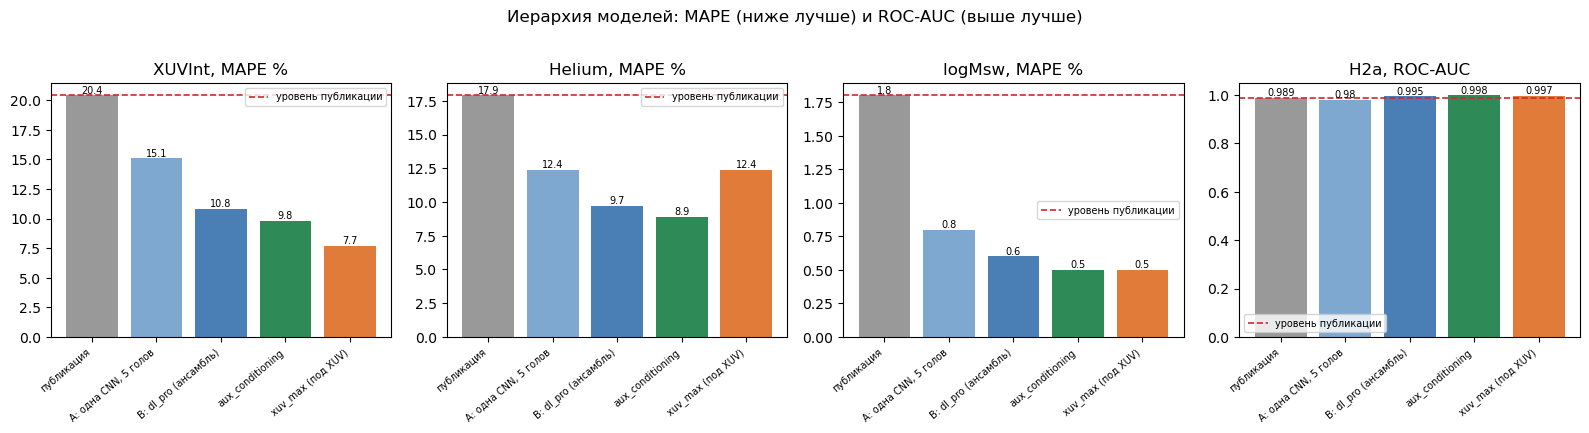

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
colors = ["#999999", "#7fa8d0", "#4a7fb5", "#2e8b57", "#e07b39"]
specs = [("xuv", "XUVInt, MAPE %", False), ("he", "Helium, MAPE %", False),
         ("msw", "logMsw, MAPE %", False), ("auc", "H2a, ROC-AUC", True)]
for ax, (key, title, higher_better) in zip(axes, specs):
    vals = [MODELS[n][key] for n in names]
    bars = ax.bar(range(len(names)), vals, color=colors)
    ref = MODELS["публикация"][key]
    ax.axhline(ref, color="tab:red", ls="--", lw=1.2,
               label="уровень публикации")
    ax.set_title(title)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=7)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f"{v:g}", ha="center",
                va="bottom", fontsize=7)
    ax.legend(fontsize=7)
plt.suptitle("Иерархия моделей: MAPE (ниже лучше) и ROC-AUC (выше лучше)", y=1.02)
plt.tight_layout()
plt.show()

**Читается так:** все наши модели ниже красной линии по MAPE (лучше статьи).
Лучшая сбалансированная — `aux_conditioning` (зелёная): бьёт всё сразу.
`xuv_max` (оранжевая) — рекордно низкий XUV (7.7%), но **высокий He (12.4%)**:
он заточен под XUV в ущерб гелию. Об этом — раздел 3.

## 2. Прямое сравнение со статьёй (с доверительными интервалами)

Модели A и B — без внешних данных, формат вывода как у статьи (одна пятёрка).
Интервалы — 95% bootstrap. Если усы не перекрываются — разница значима.

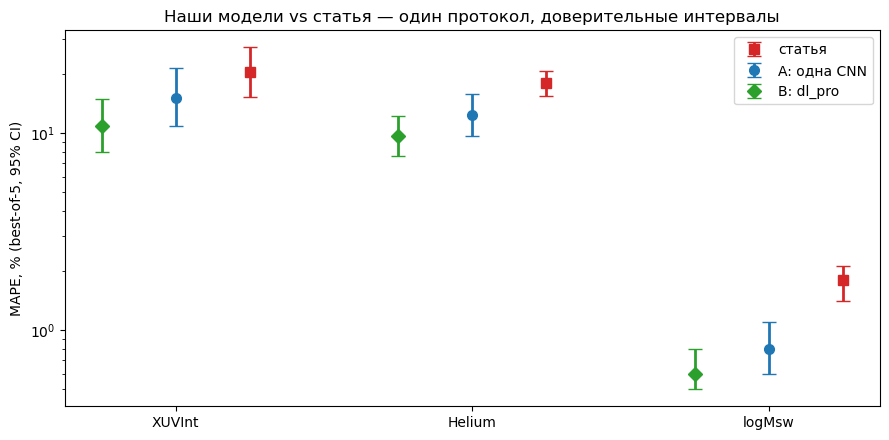

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
tg = ["XUVInt", "Helium", "logMsw"]
# (значение, низ CI, верх CI) из paper_comparison.ipynb
data = {
    "статья":           [(20.4,15.2,27.2),(17.9,15.4,20.6),(1.8,1.4,2.1)],
    "A: одна CNN":       [(15.1,10.8,21.4),(12.4,9.7,15.8),(0.8,0.6,1.1)],
    "B: dl_pro":         [(10.8,8.0,14.8),(9.7,7.6,12.2),(0.6,0.5,0.8)],
}
xs = np.arange(3)
offs = {"статья":0.25,"A: одна CNN":0.0,"B: dl_pro":-0.25}
cols = {"статья":"tab:red","A: одна CNN":"tab:blue","B: dl_pro":"tab:green"}
mk = {"статья":"s","A: одна CNN":"o","B: dl_pro":"D"}
for name,rows in data.items():
    v=[r[0] for r in rows]; lo=[r[0]-r[1] for r in rows]; hi=[r[2]-r[0] for r in rows]
    ax.errorbar(xs+offs[name], v, yerr=[lo,hi], fmt=mk[name], capsize=5,
                color=cols[name], label=name, markersize=7, lw=2)
ax.set_xticks(xs); ax.set_xticklabels(tg)
ax.set_ylabel("MAPE, % (best-of-5, 95% CI)")
ax.set_yscale("log")
ax.set_title("Наши модели vs статья — один протокол, доверительные интервалы")
ax.legend()
plt.tight_layout()
plt.show()

**Читается так:** по Helium интервалы вообще не перекрываются
(наш верх 15.8 < их низ 15.4) — статистически значимо лучше. По XUV и logMsw
наши точки тоже ниже. Даже простейшая модель A (одна CNN) бьёт публикацию.

## 3. Почему `xuv_max` не сравнивают со статьёй «в целом»

Ключевой момент, из-за которого путаница. Загружаем кэш кандидатов
(`aux_data/xuv_candidates.npz`: 56 кандидатов на профиль + скоры ранкера) и
показываем: **чтобы получить лучший XUV, нужна одна пятёрка; для лучшего He —
другая. Единой пятёрки для обоих нет.**

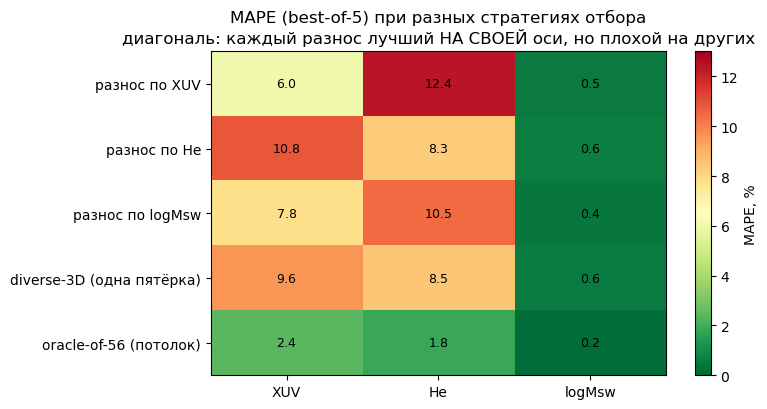

разнос по XUV: XUV=6.0 (лучший!) но He=12.4 (плохой)
разнос по He:  He=8.3 (лучший!) но XUV=10.8


In [4]:
d = np.load("aux_data/xuv_candidates.npz")
cands, y_true, scores = d["candidates"], d["y_true"], d["scores"]
y_mean, y_std = d["y_mean"], d["y_std"]
N, K, _ = cands.shape
true_lin = 10 ** y_true

def best_of_5(sel, j, log=False):
    s = np.take_along_axis(cands[:, :, j], sel, 1)
    if log:
        return 100*np.mean(np.abs(s - y_true[:, j:j+1]).min(1)/np.abs(y_true[:, j]))
    return 100*np.mean(np.abs(10**s - true_lin[:, j:j+1]).min(1)/true_lin[:, j])

def spread(cvals, s, M=20, k=5):
    top = np.argsort(-s)[:M]; ch=[top[0]]
    for _ in range(k-1):
        bj,bg=None,-1e9
        for j in top:
            if j in ch: continue
            g=min(abs(cvals[j]-cvals[i]) for i in ch)
            if g>bg: bg,bj=g,j
        ch.append(bj)
    return ch
def diverse3d(c,s,k=5):
    cn=(c-y_mean)/y_std; order=np.argsort(-s); ch=[order[0]]
    for _ in range(k-1):
        bj,bg=None,-1e9
        for j in order:
            if j in ch: continue
            g=min(np.linalg.norm(cn[j]-cn[i]) for i in ch)+0.02*s[j]
            if g>bg: bg,bj=g,j
        ch.append(bj)
    return ch

selX=np.array([spread(cands[i,:,0],scores[i]) for i in range(N)])
selH=np.array([spread(cands[i,:,1],scores[i]) for i in range(N)])
selM=np.array([spread(cands[i,:,2],scores[i]) for i in range(N)])
sel3=np.array([diverse3d(cands[i],scores[i]) for i in range(N)])
allidx=np.tile(np.arange(K),(N,1))

rows=[("разнос по XUV",selX),("разнос по He",selH),
      ("разнос по logMsw",selM),("diverse-3D (одна пятёрка)",sel3),
      ("oracle-of-56 (потолок)",allidx)]
M=np.array([[best_of_5(s,0),best_of_5(s,1),best_of_5(s,2,True)] for _,s in rows])

fig, ax = plt.subplots(figsize=(8,4.2))
im=ax.imshow(M, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=13)
ax.set_xticks(range(3)); ax.set_xticklabels(["XUV","He","logMsw"])
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows])
for i in range(len(rows)):
    for j in range(3):
        ax.text(j,i,f"{M[i,j]:.1f}",ha="center",va="center",fontsize=9,
                color="black")
ax.set_title("MAPE (best-of-5) при разных стратегиях отбора\n"
             "диагональ: каждый разнос лучший НА СВОЕЙ оси, но плохой на других")
plt.colorbar(im,ax=ax,label="MAPE, %")
plt.tight_layout(); plt.show()
print("разнос по XUV: XUV=%.1f (лучший!) но He=%.1f (плохой)"%(M[0,0],M[0,1]))
print("разнос по He:  He=%.1f (лучший!) но XUV=%.1f"%(M[1,1],M[1,0]))

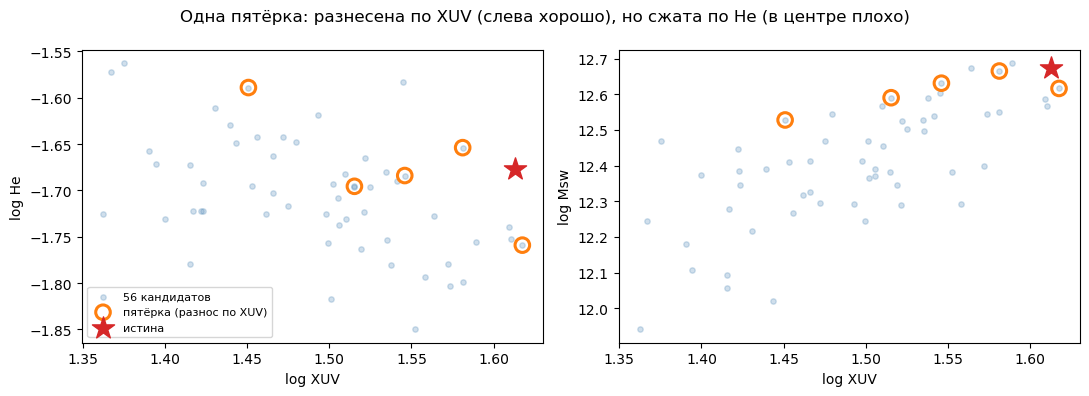

In [5]:
# та же пятёрка (разнос по XUV) на двух осях: покрывает XUV, но сжата по He
i = 11
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax,(jx,jy,nx,ny) in zip(axes,[(0,1,"log XUV","log He"),(0,2,"log XUV","log Msw")]):
    ax.scatter(cands[i,:,jx],cands[i,:,jy],s=15,alpha=0.25,color="steelblue",
               label="56 кандидатов")
    ax.scatter(cands[i,selX[i],jx],cands[i,selX[i],jy],s=110,facecolors="none",
               edgecolors="tab:orange",linewidths=2.2,label="пятёрка (разнос по XUV)")
    ax.scatter(y_true[i,jx],y_true[i,jy],marker="*",s=280,color="tab:red",
               label="истина",zorder=5)
    ax.set_xlabel(nx); ax.set_ylabel(ny)
axes[0].legend(fontsize=8)
plt.suptitle("Одна пятёрка: разнесена по XUV (слева хорошо), но сжата по He (в центре плохо)")
plt.tight_layout(); plt.show()

**Читается так:** оранжевая пятёрка широко покрывает ось XUV (левый график —
истина-звезда внутри), но по оси He те же 5 точек сбиты в кучу (правее звезда
может оказаться вне). Поэтому у `xuv_max` нет **единого** набора из 5 ответов,
хорошего сразу по всем таргетам — числа 7.7% (XUV) и 8.3% (He) берутся из
**разных** пятёрок. У статьи и у `dl_pro` — одна общая пятёрка на все таргеты.

## 4. Почему best-of-k — спорная метрика

Метрика best-of-k падает с ростом k **механически**, даже без всякой модели —
достаточно раскидать k значений по диапазону. Значит сравнивать можно только
при одинаковом k.

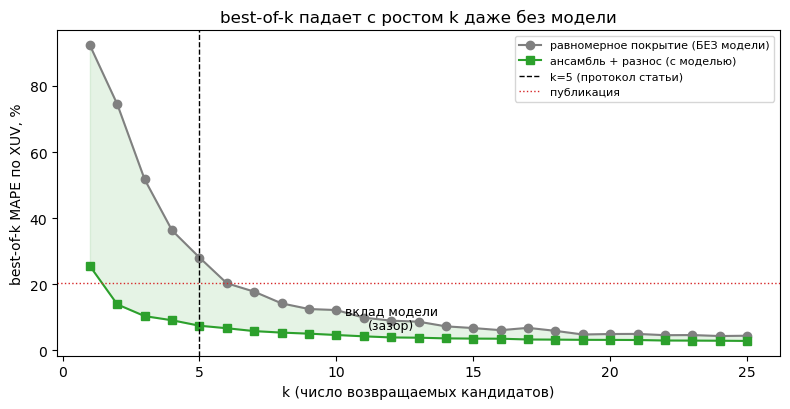

без модели: k=5→28%, k=20→5% (метрика 'улучшается' сама)


In [6]:
y_train = d["y_train"]
def bo_values(vals):
    v=np.tile(vals,(N,1))
    return 100*np.mean(np.abs(10**v-true_lin[:,0:1]).min(1)/true_lin[:,0])
ks=np.arange(1,26)
null=[bo_values(np.linspace(y_train[:,0].min(),y_train[:,0].max(),k)) for k in ks]
model=[best_of_5(np.array([spread(cands[i,:,0],scores[i],max(2*k,8),k) for i in range(N)]),0) for k in ks]

fig,ax=plt.subplots(figsize=(8,4.2))
ax.plot(ks,null,"o-",color="gray",label="равномерное покрытие (БЕЗ модели)")
ax.plot(ks,model,"s-",color="tab:green",label="ансамбль + разнос (с моделью)")
ax.axvline(5,color="k",ls="--",lw=1,label="k=5 (протокол статьи)")
ax.axhline(20.4,color="tab:red",ls=":",lw=1,label="публикация")
ax.fill_between(ks,model,null,alpha=0.12,color="tab:green")
ax.annotate("вклад модели\n(зазор)", xy=(12,(null[11]+model[11])/2),
            fontsize=9, ha="center")
ax.set_xlabel("k (число возвращаемых кандидатов)")
ax.set_ylabel("best-of-k MAPE по XUV, %")
ax.set_title("best-of-k падает с ростом k даже без модели")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"без модели: k=5→{null[4]:.0f}%, k=20→{null[19]:.0f}% (метрика 'улучшается' сама)")

**Читается так:** серая кривая (нулевая модель) тоже падает с ростом k —
при k=20 даёт ~5% вообще без обучения. Значит нельзя сравнивать методы при
разном k. При фиксированном k=5 (как у нас и статьи) зазор между зелёной и
серой — это реальный вклад модели.

## 5. Итоговая шпаргалка: что честно, что нет

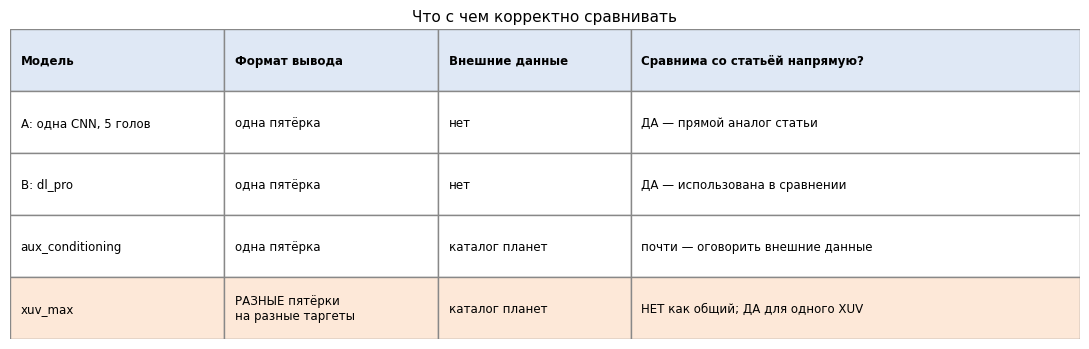

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.axis("off")
rows = [
    ["Модель", "Формат вывода", "Внешние данные", "Сравнима со статьёй напрямую?"],
    ["A: одна CNN, 5 голов", "одна пятёрка", "нет", "ДА — прямой аналог статьи"],
    ["B: dl_pro", "одна пятёрка", "нет", "ДА — использована в сравнении"],
    ["aux_conditioning", "одна пятёрка", "каталог планет", "почти — оговорить внешние данные"],
    ["xuv_max", "РАЗНЫЕ пятёрки\nна разные таргеты", "каталог планет", "НЕТ как общий; ДА для одного XUV"],
]
colw=[0.20,0.20,0.18,0.42]
xpos=np.cumsum([0]+colw)
for r,row in enumerate(rows):
    for c,txt in enumerate(row):
        face = "#dfe8f5" if r==0 else ("#fde8d8" if r==4 else "white")
        ax.add_patch(mpatches.Rectangle((xpos[c],1-(r+1)*0.2),colw[c],0.2,
                     facecolor=face,edgecolor="#888"))
        ax.text(xpos[c]+0.01,1-(r+0.5)*0.2,txt,va="center",ha="left",
                fontsize=8.5,weight="bold" if r==0 else "normal")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title("Что с чем корректно сравнивать",fontsize=11)
plt.tight_layout(); plt.show()

## Короткий итог

* **Лучшая честная модель для сравнения со статьёй — B (`dl_pro`)**: без внешних
  данных, одна пятёрка на все таргеты, бьёт статью по всем метрикам (раздел 2).
* **Лучшая сбалансированная вообще — `aux_conditioning`** (9.8/8.9/0.5/0.998),
  но использует каталог планет — оговаривается.
* **`xuv_max` — рекорд по XUV (7.7%)**, но разным таргетам нужны разные пятёрки
  (раздел 3), поэтому это результат «по одному таргету», а не общий.
* **best-of-k надо сравнивать только при фиксированном k** (раздел 4); мы и
  статья используем k=5, так что сравнение корректно.